# Parquet Pipeline

In [148]:
%load_ext autoreload
%autoreload 2

import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from convert_calorimeter import write_calohits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


### Roadmap

- Load parquet files (tracks, tracker_hits, calo_hits, particles)
- Calculate the run that corresponds to that event
- Load edm4hep file (edm4hep.root), looking just at that event
- Using position and vertex merges, ensure that ALL hits and particles are present in the edm4hep file
- Visualise the event (hits, tracks)
- Deduce the hepmc file and event number from the edm4hep event
- Load the hepmc file and event number in hard scatter AND merged versions
- Ensure that ALL generator particles are present in the hepmc files and vice versa

## Testing parquet outputs

In [150]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import awkward as ak

def load_all_particles_parquet(parquet_path, event_id=None):
    """
    Load particles data from Parquet file using awkward arrays for fast exploding.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data (flat format with one row per particle)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        # Filter to specific event
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding by examining first non-event_id column
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    # If it's not a list, data is already flat
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward array for fast exploding
    # Convert to awkward array - use ak.from_iter for nested Python lists
    ak_dict = {}
    
    # Convert each column to awkward array
    for col in df.columns:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            # For nested columns, use tolist() to convert properly
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten/explode all nested lists
    flat_dict = {}
    
    # For event_id, we need to repeat it based on the length of the nested arrays
    list_lens = ak.num(ak_dict[non_event_cols[0]])
    flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_event_cols[0]])[0])
    
    # For list columns, just flatten them
    for col in non_event_cols:
        flat_dict[col] = ak.flatten(ak_dict[col])
    
    # Convert back to pandas
    result = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    return result


def load_all_digihits_parquet(parquet_path, event_id=None):
    """
    Load digihits data from Parquet file using awkward arrays.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data (flat format with one row per hit)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward for fast exploding
    ak_dict = {}
    for col in df.columns:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten
    flat_dict = {}
    list_lens = ak.num(ak_dict[non_event_cols[0]])
    flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_event_cols[0]])[0])
    
    for col in non_event_cols:
        flat_dict[col] = ak.flatten(ak_dict[col])
    
    result = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    return result


def load_all_tracks_parquet(parquet_path, event_id=None):
    """
    Load tracks data from Parquet file using awkward arrays.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame(), None
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame(), None
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df, None
    
    first_val = df[non_event_cols[0]].iloc[0]
    
    # If already flat
    if not isinstance(first_val, (list, np.ndarray)):
        if 'hit_ids' in df.columns:
            hits_df = df[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df, None
    
    # Use awkward for fast exploding
    has_hit_ids = 'hit_ids' in df.columns
    
    # Separate hit_ids from other columns
    track_cols = [c for c in non_event_cols if c != 'hit_ids']
    
    # Convert to awkward arrays
    ak_dict = {}
    for col in ['event_id'] + track_cols:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten track data
    flat_dict = {}
    if track_cols:
        list_lens = ak.num(ak_dict[track_cols[0]])
        flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[track_cols[0]])[0])
        
        for col in track_cols:
            flat_dict[col] = ak.flatten(ak_dict[col])
    
    tracks_df = pd.DataFrame({k: ak.to_numpy(v) for k, v in flat_dict.items()})
    
    # Handle hit_ids separately if present
    hits_df = None
    if has_hit_ids and 'track_id' in tracks_df.columns:
        # hit_ids is a list of lists - need to keep as lists in the output
        ak_hit_ids = ak.Array(df['hit_ids'].tolist())
        
        # Get track_id and event_id (already flattened)
        flat_hit_dict = {
            'event_id': flat_dict['event_id'],
            'track_id': flat_dict['track_id'],
            'hit_ids': ak.flatten(ak_hit_ids)  # Flatten outer list, keep inner lists
        }
        
        # Convert to pandas, but keep hit_ids as lists
        hits_df = pd.DataFrame({
            'event_id': ak.to_numpy(flat_hit_dict['event_id']),
            'track_id': ak.to_numpy(flat_hit_dict['track_id']),
            'hit_ids': ak.to_list(flat_hit_dict['hit_ids'])  # Keep as Python lists
        })
    
    return tracks_df, hits_df


def load_all_calohits_parquet(parquet_path, event_id=None):
    """
    Load calorimeter hits data from Parquet file using awkward arrays.
    
    Calorimeter data has nested contribution lists (particle IDs, energies, times)
    that are kept as lists in the output, representing multiple particle contributions
    to each cell.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with calorimeter hits (flat format with one row per cell, 
        with nested contribution lists preserved)
    """
    # Read parquet file
    df = pd.read_parquet(parquet_path)
    
    if df.empty:
        return pd.DataFrame()
    
    if event_id is not None:
        df = df[df['event_id'] == event_id]
        if df.empty:
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df
    
    # Identify contribution columns (nested lists that should be preserved)
    contrib_cols = [c for c in df.columns if c.startswith('contrib_')]
    
    # Get first non-contribution column to check if data needs exploding
    non_contrib_cols = [c for c in non_event_cols if c not in contrib_cols]
    if not non_contrib_cols:
        return df
    
    first_val = df[non_contrib_cols[0]].iloc[0]
    
    # If it's not a list, data is already flat
    if not isinstance(first_val, (list, np.ndarray)):
        return df
    
    # Use awkward for fast exploding
    # Separate scalar columns from contribution columns
    scalar_cols = [c for c in df.columns if c not in contrib_cols]
    
    # Convert scalar columns to awkward arrays
    ak_dict = {}
    for col in scalar_cols:
        if col == 'event_id':
            ak_dict[col] = ak.Array(df[col].tolist())
        else:
            ak_dict[col] = ak.Array(df[col].tolist())
    
    # Flatten scalar columns
    flat_dict = {}
    if non_contrib_cols:
        list_lens = ak.num(ak_dict[non_contrib_cols[0]])
        flat_dict['event_id'] = ak.flatten(ak.broadcast_arrays(ak_dict['event_id'], ak_dict[non_contrib_cols[0]])[0])
        
        for col in non_contrib_cols:
            flat_dict[col] = ak.flatten(ak_dict[col])
    
    # Handle contribution columns separately - flatten outer list but keep inner lists
    for col in contrib_cols:
        if col in df.columns:
            ak_col = ak.Array(df[col].tolist())
            flat_dict[col] = ak.to_list(ak.flatten(ak_col))
    
    # Convert back to pandas
    result = pd.DataFrame(flat_dict)
    return result


In [151]:
global_event_id = 9
chunk_size = 10
chunk_number = global_event_id // chunk_size
event_range = f"events{chunk_number*chunk_size}-{chunk_number*chunk_size+chunk_size-1}"

In [152]:
event_range

'events0-9'

In [153]:
# Update file paths to point to parquet files
particles_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/parquet/truth/particles/hard_scatter.ttbar.v1.truth.particles.{event_range}.parquet"
digihits_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/parquet/reco/tracker_hits/hard_scatter.ttbar.v1.reco.tracker_hits.{event_range}.parquet"
tracks_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/parquet/reco/tracks/hard_scatter.ttbar.v1.reco.tracks.{event_range}.parquet"
calohits_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/parquet/reco/calo_hits/hard_scatter.ttbar.v1.reco.calo_hits.{event_range}.parquet"

In [154]:
# Test loading a single event from parquet with improved functions
parquet_particles_df = load_all_particles_parquet(particles_file, event_id=global_event_id)
parquet_trackerhits_df = load_all_digihits_parquet(digihits_file, event_id=global_event_id)
parquet_tracks_df, parquet_track_hits_df = load_all_tracks_parquet(tracks_file, event_id=global_event_id)
parquet_calohits_df = load_all_calohits_parquet(calohits_file, event_id=global_event_id)

print(f"Loaded event {global_event_id}:")
print(f"  Particles: {len(parquet_particles_df)} rows")
print(f"  Digihits: {len(parquet_trackerhits_df)} rows")
print(f"  Tracks: {len(parquet_tracks_df)} rows")
print(f"  Calohits: {len(parquet_calohits_df)} rows")
if parquet_track_hits_df is not None:
    print(f"  Track hit associations: {len(parquet_track_hits_df)} rows")

print("\nParticles sample:")
print(parquet_particles_df.head() if not parquet_particles_df.empty else "Empty")

print("\nDigihits sample:")
print(parquet_trackerhits_df.head() if not parquet_trackerhits_df.empty else "Empty")

print("\nTracks sample:")
print(parquet_tracks_df.head() if not parquet_tracks_df.empty else "Empty")

Loaded event 9:
  Particles: 729 rows
  Digihits: 5145 rows
  Tracks: 52 rows
  Calohits: 34202 rows
  Track hit associations: 52 rows

Particles sample:
   event_id  particle_id  pdg_id      mass      energy  charge        vx  \
0         9           38     111  0.134980   30.772015     0.0  0.006688   
1         9           39     311  0.497610   44.924041     0.0  0.006688   
2         9           40    -321  0.493680  240.415275    -1.0  0.006688   
3         9           41     211  0.139570  219.322209     1.0  0.006688   
4         9           42     313  0.888198  724.485975     0.0  0.006688   

         vy         vz      time        px        py          pz  \
0  0.007428  41.276291  7.328874 -0.123999  1.023327   30.754450   
1  0.007428  41.276291  7.328874  0.375659  0.348443   44.918362   
2  0.007428  41.276291  7.328874 -0.592847  0.658431  240.413132   
3  0.007428  41.276291  7.328874  0.637481 -0.541801  219.320572   
4  0.007428  41.276291  7.328874 -1.286043  0.199

In [155]:
parquet_particles_df

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id
0,9,38,111,0.134980,30.772015,0.0,0.006688,0.007428,41.276291,7.328874,-0.123999,1.023327,30.754450,1,9.0
1,9,39,311,0.497610,44.924041,0.0,0.006688,0.007428,41.276291,7.328874,0.375659,0.348443,44.918362,1,9.0
2,9,40,-321,0.493680,240.415275,-1.0,0.006688,0.007428,41.276291,7.328874,-0.592847,0.658431,240.413132,1,9.0
3,9,41,211,0.139570,219.322209,1.0,0.006688,0.007428,41.276291,7.328874,0.637481,-0.541801,219.320572,1,9.0
4,9,42,313,0.888198,724.485975,0.0,0.006688,0.007428,41.276291,7.328874,-1.286043,0.199612,724.484253,1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,9,6917,-211,0.139570,0.706931,-1.0,52.628674,-512.668579,-1295.527466,12.161613,-0.126760,-0.385255,-0.561945,1,492.0
725,9,6918,2212,0.938272,1.235285,1.0,52.628674,-512.668579,-1295.527466,12.161613,-0.191756,-0.511629,-0.589102,1,492.0
726,9,6940,2112,0.939565,0.940273,0.0,-275.367859,-629.169556,-3234.081787,37.115234,0.003606,0.016483,0.032321,1,6939.0
727,9,6943,11,0.000511,2.027154,-1.0,87.558205,-82.154915,-440.135162,8.983879,0.358524,-0.333891,-1.967062,1,6942.0


In [156]:
parquet_trackerhits_df

,event_id,x,y,z,true_x,true_y,true_z,time,particle_id,cell_id,detector,volume_id,layer_id,surface_id
0,9,70.425003,5.225000,-1515.599976,70.425575,5.207473,-1515.599976,12.527770,644,17145509445735,1,16,4,1
1,9,46.030842,8.625362,-1515.599976,46.045303,8.627640,-1515.599976,12.753895,5198,16849156702311,1,16,4,1
2,9,66.630913,29.371147,-1516.800049,66.619293,29.377815,-1516.839355,12.752678,6843,34226594382951,1,16,4,2
3,9,46.068565,8.021757,-1516.800049,46.073795,8.024987,-1516.800049,12.758412,5198,356482286695,1,16,4,2
4,9,-46.678593,24.900305,-1515.599976,-46.666790,24.896931,-1515.599976,12.532757,5259,17441862199399,1,16,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5140,9,683.970825,716.756348,3020.500000,737.710144,768.367676,3020.500000,18.262096,4894,661426037086,5,30,12,186
5141,9,560.254639,819.338257,3004.500000,566.203186,826.806030,3004.500000,18.509542,2932,16037407912286,5,30,12,187
5142,9,563.261047,814.428650,3009.500000,570.604492,824.396851,3009.500000,18.533272,2932,16192027783518,5,30,12,188
5143,9,403.131714,904.012024,3004.500000,427.592133,959.875244,3004.500000,17.857859,283,760209248606,5,30,12,191


In [157]:
parquet_tracks_df

,event_id,d0,z0,phi,theta,qop,majority_particle_id,track_id
0,9,0.041574,40.137188,2.378237,0.104417,-0.046077,258,58
1,9,0.888239,47.079178,2.299737,0.144572,0.053459,809,57
2,9,-0.002662,41.280403,2.300429,0.477496,0.161473,744,56
3,9,-0.043865,41.695808,2.060489,0.125982,-0.064213,680,55
4,9,-0.073346,41.193699,2.147089,0.431093,0.146359,749,54
5,9,-0.009112,41.288158,2.043336,0.769020,-0.439266,745,53
6,9,-0.032046,41.644966,1.910536,0.154076,-0.085794,682,52
7,9,-0.049857,41.409340,1.818992,0.169091,0.134209,693,51
8,9,-0.001450,41.328159,1.688115,0.420064,-0.124135,705,50
9,9,1.007157,41.144894,1.532550,0.363362,-0.189073,287,47


In [158]:
parquet_track_hits_df

,event_id,track_id,hit_ids
0,9,58,"[726, 1382, 1461, 1533, 1609, 1717, 1800, 1885..."
1,9,57,"[718, 1386, 1464, 1545, 1625, 1715, 3475, 3595..."
2,9,56,"[739, 827, 1035, 1237, 2392, 2674, 2921, 2916,..."
3,9,55,"[701, 1379, 1456, 1530, 1621, 1710, 1794, 3591..."
4,9,54,"[715, 740, 822, 1033, 1234, 2389, 2657, 2913, ..."
5,9,53,"[714, 811, 821, 1032, 1235, 2391, 2388, 2654, ..."
6,9,52,"[700, 810, 1375, 1452, 1470, 1542, 1619, 1709]"
7,9,51,"[682, 699, 975, 1376, 1467, 1541, 1618, 3358, ..."
8,9,50,"[690, 979, 1019, 1216, 2377, 2636, 2633, 3325,..."
9,9,47,"[965, 1015, 1213, 2371, 2634, 2629, 3290, 3288..."


In [159]:
parquet_calohits_df

,event_id,detector,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times
0,9,ECalBarrelCollection,0.000417,-239.699997,1252.400024,2111.399902,[715],[0.0004169316089246422],[15.67170524597168]
1,9,ECalBarrelCollection,0.000299,-244.800003,1257.449951,2121.600098,[715],[0.00029895020998083055],[15.707788467407227]
2,9,ECalBarrelCollection,0.000530,-244.800003,1262.500000,2131.800049,[715],[0.0005295283626765013],[15.744013786315918]
3,9,ECalBarrelCollection,0.000292,-249.899994,1267.550049,2136.899902,[715],[0.0002916482335422188],[15.780496597290039]
4,9,ECalBarrelCollection,0.000313,-249.899994,1272.599976,2147.100098,[715],[0.00031293107895180583],[15.816831588745117]
...,...,...,...,...,...,...,...,...,...
34197,9,HCalEndcapCollection,0.003268,-871.501038,1947.202026,4514.500000,[6582],[0.003268220229074359],[24.806690216064453]
34198,9,HCalEndcapCollection,0.000698,-277.531708,-235.105301,-4718.500000,[6834],[0.0006977427983656526],[23.821964263916016]
34199,9,HCalEndcapCollection,0.000867,-319.958130,-235.105301,-4769.500000,[6834],[0.0008673271513544023],[24.038660049438477]
34200,9,HCalEndcapCollection,0.000599,-395.084412,-228.592865,-4871.500000,[6834],[0.000599387101829052],[24.482919692993164]


## Validation Checks

In [92]:
# Add number of hits to particles_df
num_tracker_hits = parquet_trackerhits_df.groupby("particle_id").size()
parquet_particles_df["num_tracker_hits"] = parquet_particles_df.particle_id.map(num_tracker_hits)
parquet_tracks_df["num_particle_hits"] = parquet_tracks_df.merge(parquet_particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
parquet_tracks_df["num_track_hits"] = parquet_track_hits_df.hit_ids.apply(len)
parquet_tracks_df["hit_ids"] = parquet_track_hits_df.hit_ids

def get_num_shared_hits(track_row):
    track_hit_ids = track_row.hit_ids
    particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_row.majority_particle_id].index.tolist()
    return len(set(track_hit_ids) & set(particle_hit_ids))

parquet_tracks_df["num_shared_hits"] = parquet_tracks_df.apply(get_num_shared_hits, axis=1)

In [93]:
parquet_tracks_df["efficiency"] = parquet_tracks_df["num_shared_hits"] / parquet_tracks_df["num_particle_hits"]
parquet_tracks_df["purity"] = parquet_tracks_df["num_shared_hits"] / parquet_tracks_df["num_track_hits"]

In [94]:
print(f"Efficiency: {parquet_tracks_df.efficiency.mean()}, Purity: {parquet_tracks_df.purity.mean()}")

Efficiency: 0.9944132978635241, Purity: 0.9883558748943364


In [ ]:
for global_event_id in range(0, 10):
    parquet_particles_df = load_all_particles_parquet(particles_file, event_id = global_event_id)
    parquet_trackerhits_df = load_all_digihits_parquet(digihits_file, event_id = global_event_id)
    parquet_tracks_df, parquet_track_hits_df = load_all_tracks_parquet(tracks_file, event_id = global_event_id)
    tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
    tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
    tracks_df["hit_ids"] = track_hits_df.hit_ids
    tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)
    tracks_df["completeness"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
    tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]
    print(f"Completeness: {tracks_df.completeness.mean()}, Purity: {tracks_df.purity.mean()}")


KeyError: "['num_tracker_hits'] not in index"

Text(0.5, 1.0, 'Track 0: Track hits vs True particle hits, track ID: 16')

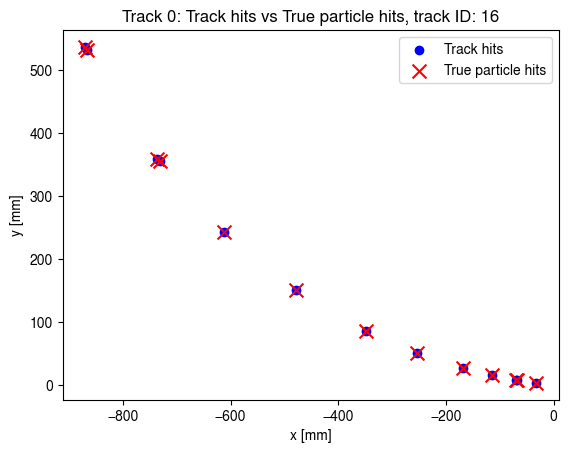

In [54]:
track_index = 0
track_hit_ids = track_hits_df.iloc[track_index].hit_ids

plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color="b", label="Track hits")

# Get the majority particle id for the track
track_majority_particle_id = tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color="red", s=100, label="True particle hits")

# Add legend
plt.legend()
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Track {track_index}: Track hits vs True particle hits, track ID: {tracks_df.track_id.iloc[track_index]}")

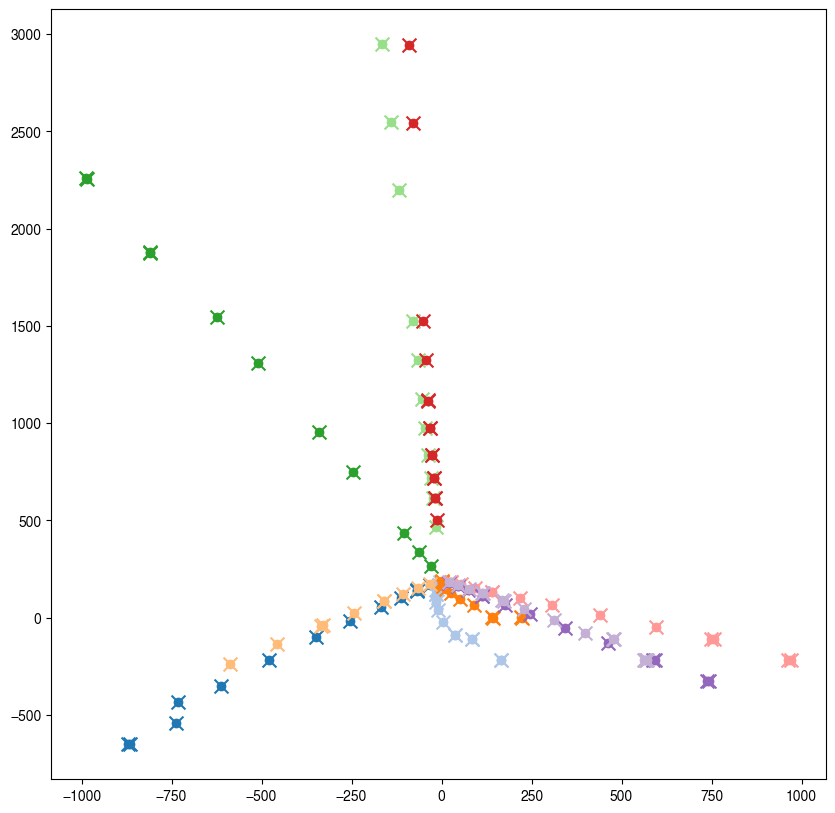

In [55]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.z.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.z.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

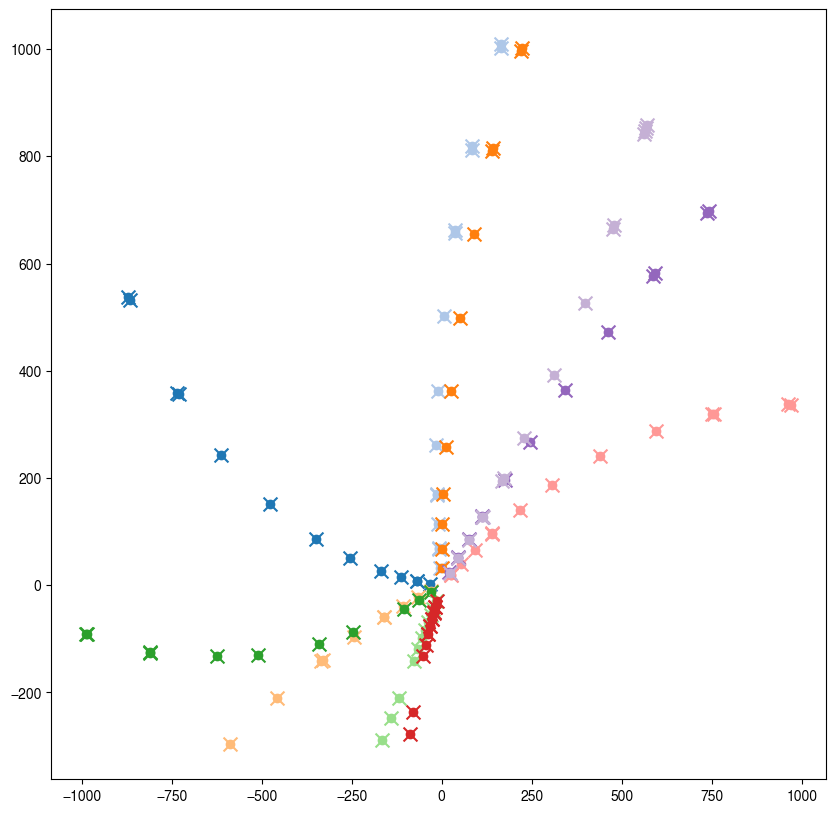

In [56]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

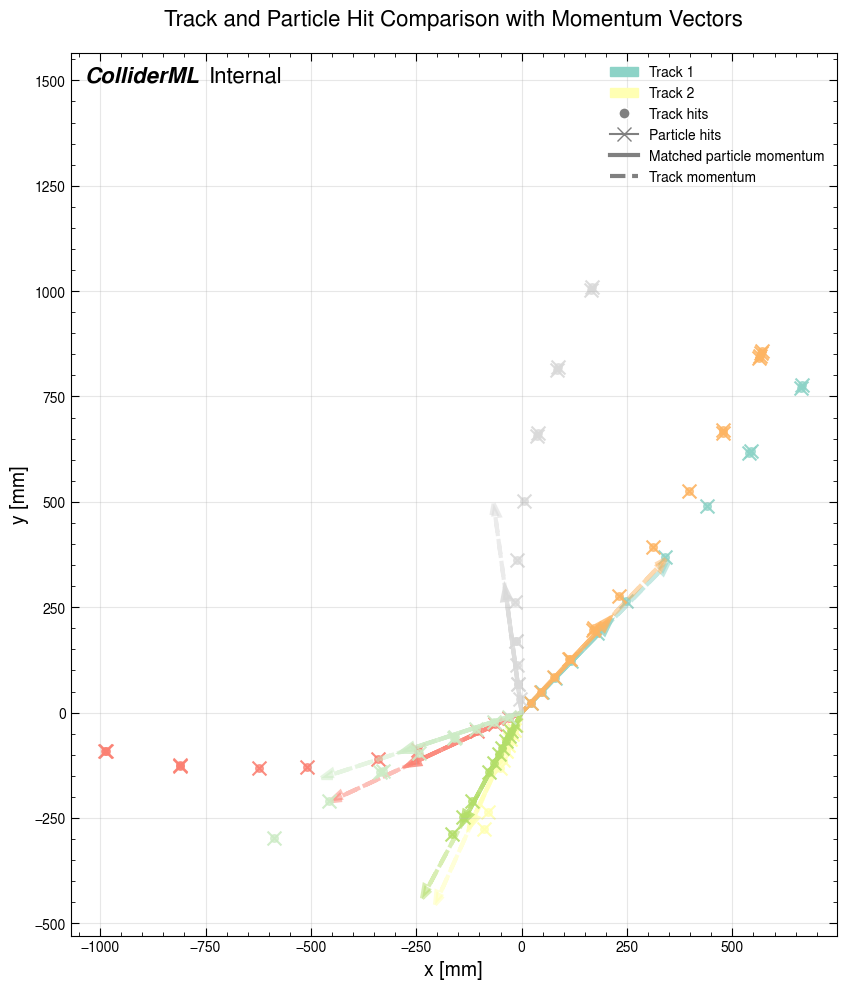

In [57]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(tracks_df), size=min(num_tracks_to_sample, len(tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = particles_df[particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()


## EDM4HEP Version

In [160]:
run_size = 1280
run_id = global_event_id // run_size
local_event = global_event_id % run_size

In [161]:
edm4hep_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/{run_id}/edm4hep.root"
edm4hep_event = EDM4hepEventBatch(str(edm4hep_file), events=(local_event, local_event+1), condense_calo=False)

2025-10-28 08:15:47,579 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0/edm4hep.root, events=(9, 10), full_load=False, condense_calo=False


In [162]:
root_file = uproot.open(edm4hep_file)["events"]

In [163]:
root_file["EventHeader/EventHeader.eventNumber"].arrays()[local_event]["EventHeader.eventNumber"].tolist()[0]

9

In [164]:
edm4hep_trackerhits_df = edm4hep_event.get_tracker_hits_df()
edm4hep_calohits_df = edm4hep_event.get_calo_hits_df()
edm4hep_contributions_df = edm4hep_event.get_calo_contributions_df()
edm4hep_particles_df = edm4hep_event.get_particles_df()

2025-10-28 08:15:58,322 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=9, stop=10
2025-10-28 08:15:58,359 - DEBUG - pyedm4hep.event_batch - tracker PixelBarrelReadout: rows=821 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-28 08:15:58,384 - DEBUG - pyedm4hep.event_batch - tracker PixelEndcapReadout: rows=1086 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-28 08:15:58,403 - DEBUG - pyedm4hep.event_batch - tracker ShortStripBarrelReadout: rows=893 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-28 08:15:58,422 - DEBUG - pyedm4hep.event_batch - tracker ShortStripEndcapReadout: rows=1194 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-28 08:15:58,442 - DEBUG - pyedm4hep.event_batch - tracker LongStripBarrelReadout: rows=442 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-28 08:15:58,461 - DEBUG - pyedm

Any NAN values:  event_id       False
subentry       False
energy         False
time           False
particle_id    False
detector       False
hit_index      False
cellID         False
x              False
y              False
z              False
dtype: bool


In [165]:
# Can we compare these?
# To compare the positions from both dataframes, let's align and rename the columns for a meaningful comparison:

# Prepare edm4hep df and rename columns to match those from parquet if needed
df1 = edm4hep_trackerhits_df.sort_values(by=["x", "y", "z"])[["x", "y", "z"]].reset_index(drop=True).astype(np.float32)
df2 = parquet_trackerhits_df.sort_values(by=["true_x", "true_y", "true_z"])[["true_x", "true_y", "true_z"]].reset_index(drop=True).astype(np.float32)
df2.columns = ["x", "y", "z"]

# Now compare for near-equality (since floats may differ by small epsilon)
comparison = (df1 - df2).abs() < 1e-4  # adjust tolerance if needed

# Check how many rows match across all columns
comparison_all = comparison.all(axis=1)
print(f"{comparison_all.sum()} out of {len(comparison_all)} hits match within tolerance.")

# Optionally, show where mismatches occur
if not comparison_all.all():
    mismatches = pd.concat([df1[~comparison_all], df2[~comparison_all]], axis=1, keys=["edm4hep", "parquet"])
    print("Mismatching hits:")
    display(mismatches)

5145 out of 5145 hits match within tolerance.


In [166]:
edm4hep_particles_df

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,9,0,2212,0,1.000000,7.328874,0.938270,0.006688,0.007428,41.276290,...,6999.999937,0,0,0.009995,7000.000000,6999.061730,0,False,0,0
1,9,1,21,0,0.000000,7.328874,0.000000,0.006688,0.007428,41.276290,...,2862.915849,0,1,0.009995,2862.915849,2862.915849,1,False,0,0
2,9,2,2203,0,1.333333,7.328874,0.771330,0.006688,0.007428,41.276290,...,4084.529394,1,2,0.009995,4084.529467,4083.758137,2,False,0,0
3,9,3,1,0,-0.333333,7.328874,0.330000,0.006688,0.007428,41.276290,...,52.554142,2,3,0.009995,52.555178,52.225178,3,False,0,0
4,9,4,2212,0,1.000000,7.328874,0.938270,0.006688,0.007428,41.276290,...,-6999.999937,3,3,0.009995,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6966,9,6966,11,1493172224,-1.000000,9.872147,0.000511,31.287727,34.968653,-719.602730,...,-0.003743,10472,10473,46.922580,0.004157,0.003646,6966,True,2,0
6967,9,6967,22,1107296256,0.000000,7.328938,0.000000,0.006821,0.007395,41.257070,...,-51.525184,10473,10474,0.010061,51.526402,51.526402,6967,True,0,0
6968,9,6968,22,1107296256,0.000000,7.328938,0.000000,0.006821,0.007395,41.257070,...,-21.087912,10474,10475,0.010061,21.088690,21.088690,6968,True,0,0
6969,9,6969,22,1107296256,0.000000,7.328886,0.000000,0.006699,0.007454,41.272482,...,-26.176710,10475,10476,0.010022,26.177106,26.177106,6969,True,0,0


In [167]:
parquet_particles_df

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id
0,9,38,111,0.134980,30.772015,0.0,0.006688,0.007428,41.276291,7.328874,-0.123999,1.023327,30.754450,1,9.0
1,9,39,311,0.497610,44.924041,0.0,0.006688,0.007428,41.276291,7.328874,0.375659,0.348443,44.918362,1,9.0
2,9,40,-321,0.493680,240.415275,-1.0,0.006688,0.007428,41.276291,7.328874,-0.592847,0.658431,240.413132,1,9.0
3,9,41,211,0.139570,219.322209,1.0,0.006688,0.007428,41.276291,7.328874,0.637481,-0.541801,219.320572,1,9.0
4,9,42,313,0.888198,724.485975,0.0,0.006688,0.007428,41.276291,7.328874,-1.286043,0.199612,724.484253,1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,9,6917,-211,0.139570,0.706931,-1.0,52.628674,-512.668579,-1295.527466,12.161613,-0.126760,-0.385255,-0.561945,1,492.0
725,9,6918,2212,0.938272,1.235285,1.0,52.628674,-512.668579,-1295.527466,12.161613,-0.191756,-0.511629,-0.589102,1,492.0
726,9,6940,2112,0.939565,0.940273,0.0,-275.367859,-629.169556,-3234.081787,37.115234,0.003606,0.016483,0.032321,1,6939.0
727,9,6943,11,0.000511,2.027154,-1.0,87.558205,-82.154915,-440.135162,8.983879,0.358524,-0.333891,-1.967062,1,6942.0


In [168]:
# Test vx, vy, vz (_x and _y are the same)
merged_particles = parquet_particles_df.merge(edm4hep_particles_df, on="particle_id", how="inner", suffixes=("_parquet", "_edm4hep"))
df1 = merged_particles[["vx_parquet", "vy_parquet", "vz_parquet", "px_parquet", "py_parquet", "pz_parquet"]].astype(np.float32)
df2 = merged_particles[["vx_edm4hep", "vy_edm4hep", "vz_edm4hep", "px_edm4hep", "py_edm4hep", "pz_edm4hep"]].astype(np.float32)
df1.columns = ["vx", "vy", "vz", "px", "py", "pz"]
df2.columns = ["vx", "vy", "vz", "px", "py", "pz"]
comparison = (df1 - df2).abs() < 1e-4  # adjust tolerance if needed
comparison_all = comparison.all(axis=1)
print(f"{comparison_all.sum()} out of {len(comparison_all)} particles match within tolerance.")

# Optionally, show where mismatches occur
if not comparison_all.all():
    mismatches = pd.concat([df1[~comparison_all], df2[~comparison_all]], axis=1, keys=["edm4hep", "parquet"])
    print("Mismatching particles:")
    delta = merged_particles[f"{col}_parquet"] - merged_particles[f"{col}_edm4hep"]
    print(f"Max delta: {delta.abs().max()}")
    print("\n")

729 out of 729 particles match within tolerance.


In [169]:
# Check that all generator particles are present from the edm4hep collection
edm4hep_generator_particles = edm4hep_particles_df[edm4hep_particles_df.created_in_simulation == False]

In [170]:
edm4hep_generator_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,9,0,2212,0,1.000000,7.328874,0.93827,0.006688,0.007428,41.27629,...,6999.999937,0,0,0.009995,7000.000000,6999.061730,0,False,0,0
1,9,1,21,0,0.000000,7.328874,0.00000,0.006688,0.007428,41.27629,...,2862.915849,0,1,0.009995,2862.915849,2862.915849,1,False,0,0
2,9,2,2203,0,1.333333,7.328874,0.77133,0.006688,0.007428,41.27629,...,4084.529394,1,2,0.009995,4084.529467,4083.758137,2,False,0,0
3,9,3,1,0,-0.333333,7.328874,0.33000,0.006688,0.007428,41.27629,...,52.554142,2,3,0.009995,52.555178,52.225178,3,False,0,0
4,9,4,2212,0,1.000000,7.328874,0.93827,0.006688,0.007428,41.27629,...,-6999.999937,3,3,0.009995,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1084,9,1084,-211,16777216,-1.000000,7.328874,0.13957,0.006688,0.007428,41.27629,...,0.281191,4590,4591,0.009995,0.343890,0.204320,1084,False,9,30
1085,9,1085,-211,16777216,-1.000000,7.328874,0.13957,0.006688,0.007428,41.27629,...,-6.486359,4591,4592,0.009995,7.172183,7.032613,1085,False,15,203
1086,9,1086,111,0,0.000000,7.328874,0.13498,0.006688,0.007428,41.27629,...,-0.940780,4592,4593,0.009995,1.262221,1.127241,1086,False,0,0
1087,9,1087,211,16777216,1.000000,7.328874,0.13957,0.006688,0.007428,41.27629,...,-3.821369,4593,4594,0.009995,4.192207,4.052637,1087,False,13,267


In [171]:
merged_particles[merged_particles.created_in_simulation == False]

,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits,num_calo_hits
0,9,38,111,0.134980,30.772015,0.0,0.006688,0.007428,41.276291,7.328874,...,1.023327,30.754449,36,40,0.009995,30.772015,30.637035,False,0,0
1,9,39,311,0.497610,44.924041,0.0,0.006688,0.007428,41.276291,7.328874,...,0.348443,44.918363,40,44,0.009995,44.924041,44.426431,False,0,0
2,9,40,-321,0.493680,240.415275,-1.0,0.006688,0.007428,41.276291,7.328874,...,0.658431,240.413136,44,48,0.009995,240.415275,239.921595,False,0,0
3,9,41,211,0.139570,219.322209,1.0,0.006688,0.007428,41.276291,7.328874,...,-0.541801,219.320569,48,52,0.009995,219.322209,219.182639,False,0,0
4,9,42,313,0.888198,724.485975,0.0,0.006688,0.007428,41.276291,7.328874,...,0.199612,724.484261,52,56,0.009995,724.485975,723.597777,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,9,1084,-211,0.139570,0.343890,-1.0,0.006688,0.007428,41.276291,7.328874,...,-0.115702,0.281191,4590,4591,0.009995,0.343890,0.204320,False,9,30
441,9,1085,-211,0.139570,7.172183,-1.0,0.006688,0.007428,41.276291,7.328874,...,2.915002,-6.486359,4591,4592,0.009995,7.172183,7.032613,False,15,203
442,9,1086,111,0.134980,1.262221,0.0,0.006688,0.007428,41.276291,7.328874,...,0.811086,-0.940780,4592,4593,0.009995,1.262221,1.127241,False,0,0
443,9,1087,211,0.139570,4.192207,1.0,0.006688,0.007428,41.276291,7.328874,...,1.631497,-3.821369,4593,4594,0.009995,4.192207,4.052637,False,13,267


Okay, so only ~50% of generator particles are present in the parquet collection.

In [143]:
edm4hep_particles_df[edm4hep_particles_df.num_tracker_hits > 0]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
249,9,249,-211,33554432,-1.0,7.328874,0.139570,0.006688,0.007428,41.276290,...,5.764231,377,404,0.009995,5.774204,5.634634,249,False,5,0
254,9,254,-211,33554432,-1.0,7.328874,0.139570,0.006688,0.007428,41.276290,...,19.210509,512,539,0.009995,19.251765,19.112195,254,False,7,0
256,9,256,211,16777216,1.0,7.328874,0.139570,0.006688,0.007428,41.276290,...,3.312568,566,593,0.009995,3.358893,3.219323,256,False,13,433
258,9,258,-321,16777216,-1.0,7.328874,0.493680,0.006688,0.007428,41.276290,...,23.353349,620,647,0.009995,23.487354,22.993674,258,False,10,536
261,9,261,211,16777216,1.0,7.328874,0.139570,0.006688,0.007428,41.276290,...,1.920428,701,728,0.009995,1.939258,1.799688,261,False,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6940,9,6940,2112,1426063360,0.0,37.115234,0.939565,-275.367859,-629.169570,-3234.081765,...,0.032321,10446,10447,686.790947,0.940273,0.000707,6940,True,1,5
6943,9,6943,11,1157627904,-1.0,8.983879,0.000511,87.558202,-82.154912,-440.135165,...,-1.967062,10449,10450,120.066099,2.027154,2.026643,6943,True,8,195
6944,9,6944,-11,1157627904,1.0,8.983879,0.000511,87.558202,-82.154912,-440.135165,...,-0.093002,10450,10451,120.066099,0.096095,0.095584,6944,True,8,20
6955,9,6955,11,1426063360,-1.0,16.452610,0.000511,534.894269,-373.217077,-2614.526698,...,-0.002246,10461,10462,652.229151,0.002488,0.001977,6955,True,1,0


In [144]:
edm4hep_particles_df[edm4hep_particles_df.num_calo_hits > 0]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
256,9,256,211,16777216,1.0,7.328874,0.139570,0.006688,0.007428,41.276290,...,3.312568,566,593,0.009995,3.358893,3.219323,256,False,13,433
258,9,258,-321,16777216,-1.0,7.328874,0.493680,0.006688,0.007428,41.276290,...,23.353349,620,647,0.009995,23.487354,22.993674,258,False,10,536
261,9,261,211,16777216,1.0,7.328874,0.139570,0.006688,0.007428,41.276290,...,1.920428,701,728,0.009995,1.939258,1.799688,261,False,4,1
269,9,269,-211,33554432,-1.0,7.328874,0.139570,0.006688,0.007428,41.276290,...,10.103960,917,944,0.009995,10.127677,9.988107,269,False,6,1
271,9,271,111,0,0.0,7.328874,0.134980,0.006688,0.007428,41.276290,...,6.977396,971,998,0.009995,6.984224,6.849244,271,False,0,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6957,9,6957,-11,1157627904,1.0,18.266613,0.000511,341.155086,-358.973910,-3200.163332,...,-0.265767,10463,10464,495.226273,0.268839,0.268328,6957,True,0,131
6958,9,6958,11,1426063360,-1.0,18.371365,0.000511,344.041579,-362.397286,-3231.245832,...,-0.513633,10464,10465,499.696309,0.518849,0.518338,6958,True,0,133
6959,9,6959,-11,1426063360,1.0,18.489346,0.000511,346.305139,-365.613048,-3266.394310,...,-0.192001,10465,10466,503.587282,0.192899,0.192388,6959,True,0,74
6962,9,6962,11,1157627904,-1.0,18.202639,0.000511,314.739769,126.525835,-3200.900141,...,-0.143986,10468,10469,339.219559,0.144794,0.144283,6962,True,0,52


In [146]:
merged_particles[merged_particles.num_tracker_hits > 0]

,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits,num_calo_hits
12,9,249,-211,0.139570,5.774204,-1.0,0.006688,0.007428,41.276291,7.328874,...,0.123398,5.764231,377,404,0.009995,5.774204,5.634634,False,5,0
17,9,254,-211,0.139570,19.251765,-1.0,0.006688,0.007428,41.276291,7.328874,...,1.189015,19.210509,512,539,0.009995,19.251765,19.112195,False,7,0
19,9,256,211,0.139570,3.358893,1.0,0.006688,0.007428,41.276291,7.328874,...,0.228247,3.312568,566,593,0.009995,3.358893,3.219323,False,13,433
21,9,258,-321,0.493680,23.487354,-1.0,0.006688,0.007428,41.276291,7.328874,...,1.695938,23.353349,620,647,0.009995,23.487354,22.993674,False,10,536
24,9,261,211,0.139570,1.939258,1.0,0.006688,0.007428,41.276291,7.328874,...,0.208099,1.920428,701,728,0.009995,1.939258,1.799688,False,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,9,6917,-211,0.139570,0.706931,-1.0,52.628674,-512.668579,-1295.527466,12.161613,...,-0.385255,-0.561945,10423,10424,515.362842,0.706931,0.567361,True,4,55
725,9,6918,2212,0.938272,1.235285,1.0,52.628674,-512.668579,-1295.527466,12.161613,...,-0.511629,-0.589102,10424,10425,515.362842,1.235285,0.297013,True,5,42
726,9,6940,2112,0.939565,0.940273,0.0,-275.367859,-629.169556,-3234.081787,37.115234,...,0.016483,0.032321,10446,10447,686.790947,0.940273,0.000707,True,1,5
727,9,6943,11,0.000511,2.027154,-1.0,87.558205,-82.154915,-440.135162,8.983879,...,-0.333891,-1.967062,10449,10450,120.066099,2.027154,2.026643,True,8,195


In [147]:
merged_particles[merged_particles.num_calo_hits > 0]

,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits,num_calo_hits
19,9,256,211,0.139570,3.358893,1.0,0.006688,0.007428,41.276291,7.328874,...,0.228247,3.312568,566,593,0.009995,3.358893,3.219323,False,13,433
21,9,258,-321,0.493680,23.487354,-1.0,0.006688,0.007428,41.276291,7.328874,...,1.695938,23.353349,620,647,0.009995,23.487354,22.993674,False,10,536
24,9,261,211,0.139570,1.939258,1.0,0.006688,0.007428,41.276291,7.328874,...,0.208099,1.920428,701,728,0.009995,1.939258,1.799688,False,4,1
32,9,269,-211,0.139570,10.127677,-1.0,0.006688,0.007428,41.276291,7.328874,...,0.657169,10.103960,917,944,0.009995,10.127677,9.988107,False,6,1
34,9,271,111,0.134980,6.984224,0.0,0.006688,0.007428,41.276291,7.328874,...,0.221694,6.977396,971,998,0.009995,6.984224,6.849244,False,0,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,9,6917,-211,0.139570,0.706931,-1.0,52.628674,-512.668579,-1295.527466,12.161613,...,-0.385255,-0.561945,10423,10424,515.362842,0.706931,0.567361,True,4,55
725,9,6918,2212,0.938272,1.235285,1.0,52.628674,-512.668579,-1295.527466,12.161613,...,-0.511629,-0.589102,10424,10425,515.362842,1.235285,0.297013,True,5,42
726,9,6940,2112,0.939565,0.940273,0.0,-275.367859,-629.169556,-3234.081787,37.115234,...,0.016483,0.032321,10446,10447,686.790947,0.940273,0.000707,True,1,5
727,9,6943,11,0.000511,2.027154,-1.0,87.558205,-82.154915,-440.135162,8.983879,...,-0.333891,-1.967062,10449,10450,120.066099,2.027154,2.026643,True,8,195
